In [58]:
using Pkg
Pkg.activate("..")
include("../src/usadel_core.jl")
using Plots
using SparseArrays
using LinearAlgebra

  Activating project at `~/dev/julia/usadel_1D`


In [59]:
#parameters and setup
Dn  = 2.0
Ds  = 1.0
ξn  = sqrt(Dn / 2.0) 
ξs  = sqrt(Ds / 2.0) 

Ln  = 20.0             
Ls  = 10.0             
dx  = 0.1              
Γin = 1e-3             

println("ξn = $ξn")
println("ξs = $ξs")
println("dx/ξn = $(dx/ξn)")
println("Ln/ξn = $(Ln/ξn)") 

ξn = 1.0
ξs = 0.7071067811865476
dx/ξn = 0.1
Ln/ξn = 20.0


In [60]:
#checks
p = setup_simulation(Ln, Ls, dx, 0.0, Γin, 1.0, 1.0, Dn, Ds)

println("N = $(p.N)")
println("i0L = $(p.i0L) → $(p.nodes[p.i0L])")
println("i0R = $(p.i0R) → $(p.nodes[p.i0R])")
println("node[1]   = $(p.nodes[1])")
println("node[N]   = $(p.nodes[p.N])")
println("D[1]      = $(p.D[1])")
println("D[end]    = $(p.D[end])")
println("Δ[1]      = $(p.Δ[1])")
println("Δ[end]    = $(p.Δ[end])")

N = 300
i0L = 200 → NS
i0R = 201 → SN
node[1]   = vacc
node[N]   = bulk
D[1]      = 2.0
D[end]    = 1.0
Δ[1]      = 0.0 + 0.0im
Δ[end]    = 1.0 + 0.0im


In [61]:
#evaluate
x_eval = -1.5 * ξn
idx    = node_index(x_eval, p)

println("x_eval = $x_eval")
println("idx    = $idx")
println("node at idx: $(p.nodes[idx])")
println("distance from interface: $(p.i0L - idx) nodes")

x_eval = -1.5
idx    = 185
node at idx: N
distance from interface: 15 nodes


In [62]:
#Newton
p_test = params(0.5, p.σn, p.σs, p.Γin, p.D, p.Δ,
                p.dx, p.N, p.Ln, p.Ls,p.i0L,p.i0R, p.nodes)

theta_0 = get_theta_0(p_test)
theta, converged, iters = newton_basic(theta_0, p_test,50,1e-10,0.5)

println("converged: $converged in $iters iterations")
println("\ntheta profile:")
println("  deep N (i=50):       $(round(theta[50],    sigdigits=4))")
println("  near interface N:    $(round(theta[p.i0L-5], sigdigits=4))")
println("  NS interface:        $(round(theta[p.i0L],  sigdigits=4))")
println("  SN interface:        $(round(theta[p.i0R],  sigdigits=4))")
println("  deep S (i=N-10):     $(round(theta[p.N-10], sigdigits=4))")
println("  bulk (i=N):          $(round(theta[p.N],    sigdigits=4))")

println("\nDOS at evaluation point (idx=$idx): $(dos_at_node(theta, idx))")

converged: true in 41 iterations

theta profile:
  deep N (i=50):       0.0002995 + 0.0008116im
  near interface N:    1.158 + 0.2981im
  NS interface:        1.502 + 0.02334im
  SN interface:        1.571 - 0.03652im
  deep S (i=N-10):     1.569 + 0.5493im
  bulk (i=N):          1.569 + 0.5493im

DOS at evaluation point (idx=185): 0.9705069598900792


In [63]:
# analytic solution for comparison
function theta_analytic(x_N, E, Γin, Dn, Ds, σn, σs)
    ω  = -im*E + Γin
    ξs = sqrt(Ds / 2.0)
    ξn = sqrt(Dn / 2.0)
    γ  = (σn * ξs) / (σs * ξn)
    θs = atan(1.0 / ω)
    
    # solve for θ₀ iteratively (Belzig eq. after eq.5)
    θ₀ = θs
    for _ in 1:1000
        rhs = γ * sqrt(ω) / (ω^2 + 1)^(1/4) * sin(θ₀/2)
        θ₀  = θs + 2*asin(rhs)
    end
    
    return 4*atan(tan(θ₀/4) * exp(-sqrt(2*ω/Dn) * x_N))
end

println("Comparison at γ=1, x=1.5ξn:")
println("E       analytic    numerical")
for E in [0.1, 0.5, 0.9, 0.99]
    p_E   = params(E, p.σn, p.σs, p.Γin, p.D, p.Δ,
                   p.dx, p.N, p.i0L, p.i0R, p.Ln, p.Ls, p.nodes)
    th0   = get_theta_0(p_E)
    th, converged, _ = newton_basic(th0, p_E)
    
    dos_num = dos_at_node(th, idx)
    dos_an  = abs(real(cos(theta_analytic(1.5*ξn, E, Γin, Dn, Ds, 1.0, 1.0))))
    
    println("$E     $(round(dos_an, sigdigits=4))      $(round(dos_num, sigdigits=4))   converged=$converged")
end

Comparison at γ=1, x=1.5ξn:
E       analytic    numerical
0.1     0.2691      0.554   converged=true
0.5     0.7389      0.9705   converged=true
0.9     1.167      1.065   converged=true
0.99     1.32      1.069   converged=true


┌ Warning: Did not converge for E=0.4421036789297659 after 50 iterations
└ @ Main ~/dev/julia/usadel_1D/src/usadel_core.jl:168
┌ Warning: Did not converge for E=1.0355886287625418 after 50 iterations
└ @ Main ~/dev/julia/usadel_1D/src/usadel_core.jl:168
┌ Warning: Did not converge for E=0.4421036789297659 after 50 iterations
└ @ Main ~/dev/julia/usadel_1D/src/usadel_core.jl:168
┌ Warning: Did not converge for E=1.0355886287625418 after 50 iterations
└ @ Main ~/dev/julia/usadel_1D/src/usadel_core.jl:168
┌ Warning: Did not converge for E=0.4421036789297659 after 50 iterations
└ @ Main ~/dev/julia/usadel_1D/src/usadel_core.jl:168
┌ Warning: Did not converge for E=1.0355886287625418 after 50 iterations
└ @ Main ~/dev/julia/usadel_1D/src/usadel_core.jl:168
┌ Warning: Did not converge for E=0.4421036789297659 after 50 iterations
└ @ Main ~/dev/julia/usadel_1D/src/usadel_core.jl:168
┌ Warning: Did not converge for E=1.0355886287625418 after 50 iterations
└ @ Main ~/dev/julia/usadel_1D/src/usa

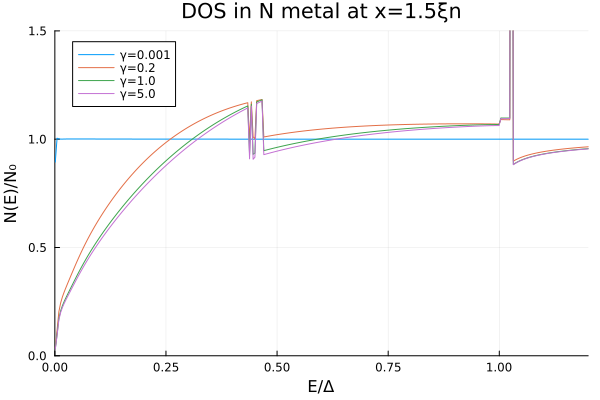

In [64]:
#compute
energies=collect(range(0.001,1.2,length=300))

# γ values from Belzig Fig. 2
γ_vals = [0.001, 0.2, 1.0, 5.0]

plt = plot(xlabel="E/Δ", ylabel="N(E)/N₀",
           title="DOS in N metal at x=1.5ξn",
           ylims=(0, 1.5), xlims=(0, 1.2),
           legend=:topleft, lw=2)

for γ in γ_vals
    σs = 1.0
    σn = γ * ξn / ξs    # from γ = σn*ξs/σs*ξn
    p_γ = setup_simulation(Ln, Ls, dx, 0.0, Γin, σn, σs, Dn, Ds)
    dos, idx = compute_DOS(energies, p_γ, x_eval)
    plot!(plt, energies, dos, label="γ=$γ")
end

display(plt)

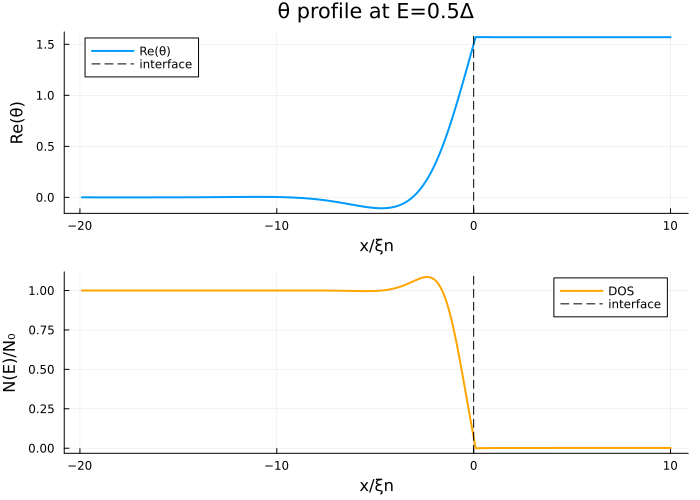

In [65]:
#verify
# visualize the theta profile across the wire at a single energy
p_E = params(0.5, p.σn, p.σs, p.Γin, p.D, p.Δ,
             p.dx, p.N, p.Ln, p.Ls, p.i0L, p.i0R, p.nodes)

theta_0 = get_theta_0(p_E)
theta, converged, iters = newton_basic(theta_0, p_E)

x_axis = [(i - p.i0L) * p.dx for i in 1:p.N]   # x=0 at interface

p1 = plot(x_axis, real.(theta),
          xlabel="x/ξn", ylabel="Re(θ)",
          title="θ profile at E=0.5Δ",
          label="Re(θ)", lw=2)

p2 = plot(x_axis, abs.(real.(cos.(theta))),
          xlabel="x/ξn", ylabel="N(E)/N₀",
          label="DOS", lw=2, color=:orange)

vline!(p1, [0.0], linestyle=:dash, color=:black, label="interface")
vline!(p2, [0.0], linestyle=:dash, color=:black, label="interface")

plot(p1, p2, layout=(2,1), size=(700,500))

In [66]:
println("i0L = ", p.i0L)
println("node_index(-1.5, p) = ", node_index(-1.5*ξn, p))
println("node_index(+1.5, p) = ", node_index(+1.5*ξn, p))

# check DOS at several positions manually
p_E = params(0.5, p.σn, p.σs, p.Γin, p.D, p.Δ,
             p.dx, p.N, p.i0L, p.i0R, p.Ln, p.Ls, p.nodes)
theta_0 = get_theta_0(p_E)
theta, _, _ = newton_basic(theta_0, p_E)

for xi in [-5.0, -3.0, -1.5, -0.5, 0.5]
    i = node_index(xi*ξn, p)
    println("x=$(xi)ξn → i=$i → DOS=$(round(dos_at_node(theta,i), sigdigits=4))")
end
println("ξn = ", sqrt(p.D[2] / 2.0))
println("dx = ", p.dx)
println("Ln = ", p.Ln)
println("x_eval = ", x_eval)
println("node_index(x_eval, p) = ", node_index(x_eval, p))
# which side has Δ=0 and which has Δ=1?
println("Δ[1]   = ", p.Δ[1])      # should be 0 (N side)
println("Δ[i0L] = ", p.Δ[p.i0L]) # should be 0 (NS node)
println("Δ[i0R] = ", p.Δ[p.i0R]) # should be 1 (SN node)
println("Δ[N]   = ", p.Δ[p.N])   # should be 1 (bulk S)

# and what is the DOS on each side at E=0.5?
p_E = params(0.5, p.σn, p.σs, p.Γin, p.D, p.Δ,
             p.dx, p.N, p.i0L, p.i0R, p.Ln, p.Ls, p.nodes)
theta_0 = get_theta_0(p_E)
theta, _, _ = newton_basic(theta_0, p_E, 50, 1e-10, 0.5)

println("\nDOS at E=0.5:")
println("  deep N (i=50):  ", dos_at_node(theta, 50))
println("  near interface N (i=190): ", dos_at_node(theta, 190))
println("  near interface S (i=210): ", dos_at_node(theta, 210))
println("  deep S (i=250): ", dos_at_node(theta, 250))

i0L = 200
node_index(-1.5, p) = 185
node_index(+1.5, p) = 216
x=-5.0ξn → i=150 → DOS=0.9974
x=-3.0ξn → i=170 → DOS=1.062
x=-1.5ξn → i=185 → DOS=0.9705
x=-0.5ξn → i=195 → DOS=0.4192
x=0.5ξn → i=206 → DOS=0.0005635
ξn = 1.0
dx = 0.1
Ln = 20.0
x_eval = -1.5
node_index(x_eval, p) = 185
Δ[1]   = 0.0 + 0.0im
Δ[i0L] = 0.0 + 0.0im
Δ[i0R] = 1.0 + 0.0im
Δ[N]   = 1.0 + 0.0im

DOS at E=0.5:
  deep N (i=50):  1.0000002845320624
  near interface N (i=190): 0.7455596955788977
  near interface S (i=210): 0.0008973329207830756
  deep S (i=250): 0.0015340603092820336


In [67]:
println("i0L = ", p.i0L)                          # 200
println("node_index(-1.5, p) = ", node_index(-1.5, p))   # should be < 200 (N side)
println("node_index(+1.5, p) = ", node_index(+1.5, p))   # should be > 200 (S side)

# what node TYPE is at the evaluation index?
idx = node_index(-1.5, p)
println("node type at idx=$idx: ", p.nodes[idx])   # should be :N


i0L = 200
node_index(-1.5, p) = 185
node_index(+1.5, p) = 216
node type at idx=185: N


In [68]:
p_test2 = setup_simulation(20.0, 10.0, 0.1, 0.0, 1e-3, 1.0, 1.0, 2.0, 1.0)
idx = node_index(-1.5, p_test2)

for E in [0.01, 0.1, 0.5, 0.9, 0.99]
    p_E = params(E, p_test2.σn, p_test2.σs, p_test2.Γin, p_test2.D, p_test2.Δ,
                 p_test2.dx, p_test2.N, p_test2.i0L, p_test2.i0R,
                 p_test2.Ln, p_test2.Ls, p_test2.nodes)
    theta_0 = get_theta_0(p_E)
    theta, converged, _ = newton_basic(theta_0, p_E, 50, 1e-10, 0.5)
    println("E=$E  DOS=$(round(dos_at_node(theta, idx), sigdigits=4))  converged=$converged")
end

E=0.01  DOS=0.1856  converged=true
E=0.1  DOS=0.554  converged=true
E=0.5  DOS=0.9705  converged=true
E=0.9  DOS=1.065  converged=true
E=0.99  DOS=1.069  converged=true
